# Entraînement d'un cnn sur le dataset des images faiblement labellisées à la 1ère étape

In [307]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [308]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [309]:
from pathlib import Path

for p in Path("/content/drive/MyDrive").iterdir():
    print(p)

/content/drive/MyDrive/Mariage_21_05_2022
/content/drive/MyDrive/Documents privés
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Document_1-107581103.pdf
/content/drive/MyDrive/L1000244.jpg
/content/drive/MyDrive/L1000245.jpg
/content/drive/MyDrive/L1000248.jpg
/content/drive/MyDrive/L1000251.jpg
/content/drive/MyDrive/L1000252.jpg
/content/drive/MyDrive/L1000253.jpg
/content/drive/MyDrive/L1000254.jpg
/content/drive/MyDrive/L1000255.jpg
/content/drive/MyDrive/SLOVENIE.docx
/content/drive/MyDrive/L1000256.jpg
/content/drive/MyDrive/Google Earth
/content/drive/MyDrive/Brain_Modelling


In [310]:
from pathlib import Path

ROOT_model = Path("/content/drive/MyDrive/Brain_Modelling/artifacts")

for p in ROOT_model.rglob("weak_labels.csv"):
    print(p)

/content/drive/MyDrive/Brain_Modelling/artifacts/weak_labels.csv


In [311]:
# Chargement du dataset

import pandas as pd

df_weak = pd.read_csv("/content/drive/MyDrive/Brain_Modelling/artifacts/weak_labels.csv")

print(df_weak.head())
print(df_weak.shape)

                                            filepath  cluster  weak_label  \
0  \Users\emman\Formation\P7 SSL\mri_dataset_brai...        0           1   
1  \Users\emman\Formation\P7 SSL\mri_dataset_brai...        1           0   
2  \Users\emman\Formation\P7 SSL\mri_dataset_brai...        0           1   
3  \Users\emman\Formation\P7 SSL\mri_dataset_brai...        0           1   
4  \Users\emman\Formation\P7 SSL\mri_dataset_brai...        0           1   

    distance  
0  21.356153  
1  14.821634  
2  15.216763  
3  18.389330  
4  17.828232  
(663, 4)


In [312]:
# Conversion des noms des fichiers images dans weak_labels.csv

from pathlib import Path, PureWindowsPath

ROOT_data = Path("/content/drive/MyDrive/Brain_Modelling/mri_dataset_brain_cancer_oc")

def convert_unlabeled_path(old_path):
    # Extraction correcte du nom de fichier depuis un chemin Windows
    filename = PureWindowsPath(old_path).name

    # Reconstruction avec le nouveau chemin Google Drive
    return str(ROOT_data / "sans_label" / "unsorted" / filename)

df_weak["filepath"] = df_weak["filepath"].apply(convert_unlabeled_path)

In [313]:
df_weak.head()

,filepath,cluster,weak_label,distance
0,/content/drive/MyDrive/Brain_Modelling/mri_dat...,0,1,21.356153
1,/content/drive/MyDrive/Brain_Modelling/mri_dat...,1,0,14.821634
2,/content/drive/MyDrive/Brain_Modelling/mri_dat...,0,1,15.216763
3,/content/drive/MyDrive/Brain_Modelling/mri_dat...,0,1,18.389330
4,/content/drive/MyDrive/Brain_Modelling/mri_dat...,0,1,17.828232


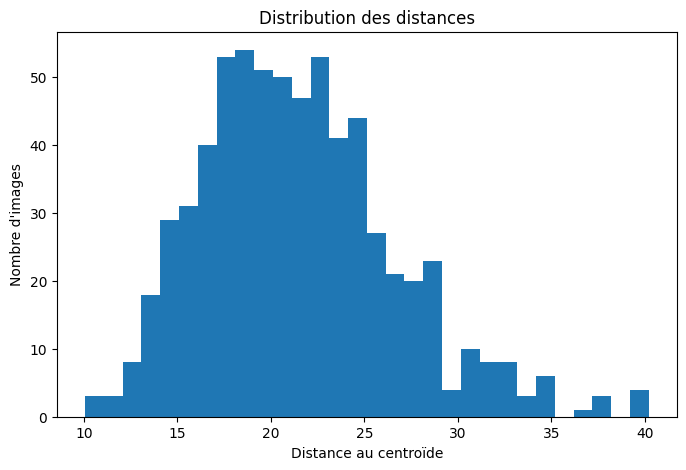

In [314]:
# On cherche à optimiser les distances entre les données et les centroïdes KMeans
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_weak["distance"], bins=30)
plt.xlabel("Distance au centroïde")
plt.ylabel("Nombre d'images")
plt.title("Distribution des distances")
plt.show()

In [315]:
# Filtrage par cluster
def kmeans_conf (df_weak, quantile):
    df_weak_conf = (
        df_weak
        .groupby("cluster", group_keys=False)
        .apply(
            lambda x:
            x[x["distance"] <= x["distance"].quantile(quantile)]
        )
        .reset_index(drop=True)
    )

    print(len(df_weak_conf))
    print(
        df_weak_conf["weak_label"].value_counts()
    )
    return df_weak_conf

In [316]:
df_weak_100 = kmeans_conf(df_weak,1.00)
df_weak_90 = kmeans_conf(df_weak,0.90)
df_weak_80 = kmeans_conf(df_weak,0.80)

663
weak_label
0    476
1    187
Name: count, dtype: int64
597
weak_label
0    428
1    169
Name: count, dtype: int64
530
weak_label
0    381
1    149
Name: count, dtype: int64


/tmp/ipykernel_2476/1019120656.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/tmp/ipykernel_2476/1019120656.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/tmp/ipykernel_2476/1019120656.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the oper

In [317]:
df_weak_80["weak_label"].value_counts()
df_weak_80["weak_label"].value_counts(normalize=True)

df_weak_90["weak_label"].value_counts()
df_weak_90["weak_label"].value_counts(normalize=True)

df_weak_100["weak_label"].value_counts()
df_weak_100["weak_label"].value_counts(normalize=True)

,proportion
weak_label,
0,0.717949
1,0.282051


In [318]:
# Récupération du df avec images labellisées en vue top
from pathlib import Path
import pandas as pd

ROOT = Path(r"/content/drive/MyDrive/Brain_Modelling/mri_dataset_brain_cancer_oc/avec_labels")

rows = []

for label_name, label in [("normal", 0), ("cancer", 1)]:
    folder = ROOT / label_name / "top"

    files = []

    for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif"]:
        files.extend(folder.glob(ext))

    for img_path in sorted(files):
        rows.append({
            "filepath": str(img_path),
            "label": label
        })

df_lab = pd.DataFrame(rows)

print(df_lab.shape)
df_lab.head()

(70, 2)


,filepath,label
0,/content/drive/MyDrive/Brain_Modelling/mri_dat...,0
1,/content/drive/MyDrive/Brain_Modelling/mri_dat...,0
2,/content/drive/MyDrive/Brain_Modelling/mri_dat...,0
3,/content/drive/MyDrive/Brain_Modelling/mri_dat...,0
4,/content/drive/MyDrive/Brain_Modelling/mri_dat...,0


In [319]:
# Split du fichier train
from sklearn.model_selection import StratifiedKFold

X = df_lab.drop(columns=["label"])
y = df_lab["label"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    df_train_strong = df_lab.iloc[train_idx]
    df_test = df_lab.iloc[test_idx]

    print(f"Fold {fold}")


Fold 0
Fold 1
Fold 2
Fold 3
Fold 4


In [320]:
print(len(df_train_strong))
print(len(df_test))

print(df_test["label"].value_counts())
print(df_train_strong["label"].value_counts())

56
14
label
0    9
1    5
Name: count, dtype: int64
label
0    39
1    17
Name: count, dtype: int64


In [321]:
# Prépa fichier weak_labels
df_weak_train = df_weak_80.rename(
    columns={"weak_label": "label"}
)
df_weak_train.head()

,filepath,cluster,label,distance
0,/content/drive/MyDrive/Brain_Modelling/mri_dat...,0,1,21.356153
1,/content/drive/MyDrive/Brain_Modelling/mri_dat...,0,1,15.216763
2,/content/drive/MyDrive/Brain_Modelling/mri_dat...,0,1,18.389330
3,/content/drive/MyDrive/Brain_Modelling/mri_dat...,0,1,17.828232
4,/content/drive/MyDrive/Brain_Modelling/mri_dat...,0,1,18.576025


In [322]:
# Modélisation avec PyTorch
import torch
from torch.utils.data import Dataset
from PIL import Image

class BrainDataset(Dataset):

    def __init__(self, df, transform=None):

        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = Image.open(
            row["filepath"]
        ).convert("L")

        if self.transform:
            img = self.transform(img)

        label = int(row["label"])

        return img, label

In [323]:
# Transformation du train
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [324]:
# Transformation du test
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [325]:
weak_dataset = BrainDataset(
    df_weak_train,
    train_transform
)

strong_train_dataset = BrainDataset(
    df_train_strong,
    train_transform
)

test_dataset = BrainDataset(
    df_test,
    test_transform
)

In [326]:
# Chargement
from torch.utils.data import DataLoader

weak_loader = DataLoader(
    weak_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

strong_loader = DataLoader(
    strong_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

In [327]:
# Chargement de DenseNet201
from torchvision.models import (
    densenet201,
    DenseNet201_Weights
)
import torch.nn as nn

model = densenet201(
    weights=DenseNet201_Weights.IMAGENET1K_V1
)

model.classifier = nn.Linear(
    model.classifier.in_features,
    2
)

In [328]:
# Gel des couches
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [329]:
# Paramétrage device
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


model = model.to(device, non_blocking=True)


In [330]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
Tesla T4


In [331]:
# Perte et optim
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3
)

In [332]:
# Fonction d'entraînement
def train_epoch(loader):

    model.train()

    running_loss = 0

    for imgs, labels in loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [333]:
# Pré-entraînement sur les labels faibles
for epoch in range(50):

    loss = train_epoch(
        weak_loader
    )

    print(
        epoch + 1,
        loss
    )

1 0.3856148285900845
2 0.20147535139146974
3 0.13789007829173522
4 0.15664446945576108
5 0.14187020655064023
6 0.08332886705722879
7 0.09493066228049643
8 0.07940574365613215
9 0.06373900194268893
10 0.0866932119242847
11 0.08248913178549093
12 0.07333121152923387
13 0.08663164155886453
14 0.08550254388383645
15 0.05581346522633206
16 0.07697858214926194
17 0.07586007652913823
18 0.04685759186909041
19 0.04466316570966121
20 0.06130359491662068
21 0.10320339358740431
22 0.08203966707429465
23 0.0596442562801873
24 0.08719976876369294
25 0.1481155318016296
26 0.11727097640087937
27 0.059516665094312936
28 0.035610162303783
29 0.06642125268220245
30 0.04392531904501512
31 0.04886200609069098
32 0.03696449720369214
33 0.042984198422773796
34 0.03853927734855782
35 0.19150355620898635
36 0.13530413520193713
37 0.18788629914086094
38 0.09162149541353916
39 0.03771639479022911
40 0.048797637128325945
41 0.05370090488234863
42 0.049525635159464884
43 0.032048174782710916
44 0.0424858913346029

In [334]:
# Fine tuning sur les labels forts
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.features.norm5.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-5
)

for epoch in range(50):

    loss = train_epoch(
        strong_loader
    )

    print(
        epoch + 1,
        loss
    )

1 0.2714056931436062
2 0.19300986966118217
3 0.15409568813629448
4 0.1765112983994186
5 0.12052468443289399
6 0.1467543295584619
7 0.14694124646484852
8 0.1572806052863598
9 0.15523836761713028
10 0.048297228291630745
11 0.03142550494521856
12 0.07765135588124394
13 0.10135612869635224
14 0.06597048765979707
15 0.10672886390239
16 0.026130596874281764
17 0.09852600353769958
18 0.11063098255544901
19 0.0421269778162241
20 0.038125914928968996
21 0.02387786260806024
22 0.015855470206588507
23 0.05281297769397497
24 0.034955695271492004
25 0.016366883530281484
26 0.040985894622281194
27 0.08190694567747414
28 0.016862086486071348
29 0.024131155107170343
30 0.030519401654601097
31 0.08009287877939641
32 0.04900961113162339
33 0.018768656300380826
34 0.04046866612043232
35 0.04509887041058391
36 0.022226658940780908
37 0.0277157073142007
38 0.09815891226753592
39 0.054957083018962294
40 0.018173364689573646
41 0.034681479912251234
42 0.023219623195473105
43 0.014593798783607781
44 0.0261652

In [335]:
if torch.cuda.is_available():
    torch.cuda.synchronize()

model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [336]:
# Evaluation
from sklearn.metrics import (
    classification_report,
    f1_score
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        outputs = model(imgs)

        preds = outputs.argmax(1)

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

print(
    classification_report(
        y_true,
        y_pred
    )
)
f1_semi = f1_score(y_true, y_pred)

print(
    "F1 :",
    f1_semi
)

              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       1.00      0.80      0.89         5

    accuracy                           0.93        14
   macro avg       0.95      0.90      0.92        14
weighted avg       0.94      0.93      0.93        14

F1 : 0.8888888888888888


In [337]:
import hashlib
import torch

torch.save(model.state_dict(), "last_model.pth")

with open("last_model.pth", "rb") as f:
    print(hashlib.md5(f.read()).hexdigest())

s = "\n".join(df_test["filepath"].tolist())
print(hashlib.md5(s.encode()).hexdigest())

e7f541f79d76e77f2a092cd7f15a9f56
dd35d157cab161c56e9552bf55ac9161


In [338]:
# Vérification données test
test_paths = set(df_test["filepath"])
weak_paths = set(df_weak_80["filepath"])

print(
    len(test_paths.intersection(
        weak_paths
    ))
)

0


In [339]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[9 0]
 [1 4]]


# Entrainement supervisé des labels forts

In [340]:
# Fonction d'évaluation
from sklearn.metrics import f1_score
import torch

def evaluate(model, loader, device):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for imgs, labels in loader:

            imgs = imgs.to(device)

            outputs = model(imgs)
            preds = outputs.argmax(1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    return f1_score(y_true, y_pred)

In [341]:
# Fonction d'entraînement
def train_epoch(model,
                loader,
                optimizer,
                criterion,
                device):

    model.train()

    running_loss = 0

    for imgs, labels in loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [342]:
# Construction du modèle
from torchvision.models import (
    resnet50,
    ResNet50_Weights
)
import torch.nn as nn

def build_model():

    model = resnet50(
        weights=ResNet50_Weights.IMAGENET1K_V2
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    return model

In [343]:
# Validation croisée
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader
import numpy as np

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

f1_scores = []

In [344]:
# Exécution par fold
for fold, (train_idx, test_idx) in enumerate(
        skf.split(df_lab,
                  df_lab["label"])):

    print(f"\nFold {fold+1}")

    df_train = (
        df_lab.iloc[train_idx]
        .reset_index(drop=True)
    )

    df_test = (
        df_lab.iloc[test_idx]
        .reset_index(drop=True)
    )

    train_dataset = BrainDataset(
        df_train,
        train_transform
    )

    test_dataset = BrainDataset(
        df_test,
        test_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False
    )

    model = build_model().to(device)


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


In [345]:
# Entraînement do modèle
for param in model.parameters():
        param.requires_grad = False

for param in model.fc.parameters():
        param.requires_grad = True

optimizer = torch.optim.Adam(
model.fc.parameters(),
lr=1e-3
)

criterion = nn.CrossEntropyLoss()

for epoch in range(10):

    loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

In [346]:
# Fine tuning
for param in model.layer4.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-5
)

for epoch in range(10):

    loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

In [347]:
# Evaluation
f1 = evaluate(
    model,
    test_loader,
    device
)

print(f"F1 : {f1:.3f}")

f1_scores.append(f1)

print(
    f"\nF1 moyen : "
    f"{np.mean(f1_scores):.3f}"
)

print(
    f"Écart-type : "
    f"{np.std(f1_scores):.3f}"
)

F1 : 0.889

F1 moyen : 0.889
Écart-type : 0.000


In [348]:
# Comparaison des entraînements semi-supervisé et supervisé
print(
    f"Supervisé      : "
    f"{np.mean(f1_scores):.3f}"
)

print(
    f"Semi-supervisé : "
    f"{np.mean(f1_semi):.3f}"
)

Supervisé      : 0.889
Semi-supervisé : 0.889
